Before we begin, make sure to install all dependencies. This can be done by running the cell below.

In [ ]:
!pip install -r requirements.txt

Now all the following imports should work.

In [2]:
from mldb.store import RunStore
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import pandas as pd
import xgboost as xgb

sns.set_theme("paper", "whitegrid")

First, let's download and store the datasets. For this example, we'll use the German dataset and the Adult dataset from the [UCI ML repository](https://archive-beta.ics.uci.edu/). Run the following cell to download and store them in the database.

In [ ]:
!python ../download_datasets.py


When the script finished, the dataset is visible in the store. Run either `mldb list` from the commandline, or run the following command in Python:

In [4]:
store = RunStore("./data")
store.list_runs(tags=["dataset"])

[RunInfo(run_id='run_2026-07-26-18:36:02_d1b72ac3_fervent_satoshi', run_name='fervent_satoshi', run_timestamp='2026-07-26 18:36:02', tags=['dataset'], hparams=[])]

Downloading the datasets created a timestamped run with a randomly generated name (awesome_proskuriakova in this case). It also stored both datasets as artifacts. These can be viewed by running `mldb artifacts` or the following Python method:

In [5]:
store.list_artifacts_by_query(tags=["dataset"])

[ArtifactInfo(run_id='run_2026-07-26-18:36:02_d1b72ac3_fervent_satoshi', artifact_name='adult', artifact_checksum='1a17b1b349f10b0b0ef84692a23ea8c66eeaa13734446deb14765aee23d6a21e_table_30162_16'),
 ArtifactInfo(run_id='run_2026-07-26-18:36:02_d1b72ac3_fervent_satoshi', artifact_name='german', artifact_checksum='1a2e62565d136e13f2f3f8beafafe526b2ea996a0371feed1834a0b864e1b2e5_table_1000_22')]

Now let's train a few models to see how we can analyze them together with the dataset. In this example, we'll compare an XGBoost model to a logistic regression model for default prediction in the German dataset. We'll first load the dataset from the store:

In [6]:
df = store.load_artifact_by_query(name="german", tags=["dataset"])

Next, we need to do some preprocessing. In the following command, note the `uuid` column. This was added inside `download_datasets.py` when we stored the datasets and will allow us to associate results we get with the initial input data. That is, it serves as our *join key* later on.

In [7]:
target = "credit_risk"
features = df.drop(columns=[target, "uuid"])
categorical_columns = features.select_dtypes(include=["object", "str"]).columns
ids = df["uuid"]
X = pd.get_dummies(features, columns=categorical_columns)
y = df.loc[:, target] - 1  # XGBoost needs 0/1 labels.
ids_train, ids_test, X_train, X_test, y_train, y_test = train_test_split(
    ids, X, y, test_size=0.2, random_state=0
)

Now we can train the first model and store its predictions for later analysis.

In [8]:
# Initialize xgboost run
xgboost_hparams = {"eval_metric": "logloss"}
run_id = store.create_run(hparams=xgboost_hparams, tags=["xgboost", "model", "german"])

# Fit an xgboost classifier and predict on all observations from both splits
model = xgb.XGBClassifier(**xgboost_hparams)
model.fit(X_train, y_train)

# Storing the observation uuid allows joining the full dataset later
for split, ids_split, X_split, y_split in zip(
    ["train", "test"], [ids_train, ids_test], [X_train, X_test], [y_train, y_test]
):
    predictions = pd.DataFrame(
        {
            "uuid": ids_split,
            "y_true": y_split,
            "predictions": model.predict(X_split),
        }
    )
    store.store(run_id, {f"predictions_{split}": predictions})

After training, we can see that a new run appeared in the database and that our predictions for each split have been stored as an artifact:

In [9]:
store.list_artifacts_by_query(tags=["model", "german"])

[ArtifactInfo(run_id='run_2026-07-26-18:36:09_6ffa2d5e_friendly_allen', artifact_name='predictions_test', artifact_checksum='db7b833793c1ff2e04f6792771e49d0ad65ca9a8734e97e7b45858bd7968fd24_table_200_3'),
 ArtifactInfo(run_id='run_2026-07-26-18:36:09_6ffa2d5e_friendly_allen', artifact_name='predictions_train', artifact_checksum='333413affdd4d878650ceaaa2916eab3e5e1b01716044882b7b37fa6458a84d5_table_800_3')]

Let's repeat those steps a second time but using a logistic regression model, so that we have something to compare.

In [10]:
# Initialize logistic regression run
logreg_hparams = {"l1_ratio": 0.5, "solver": "saga"}
run_id = store.create_run(hparams=logreg_hparams, tags=["logreg", "model", "german"])

# Fit an xgboost classifier and predict on all observations from both splits
model = LogisticRegression(**logreg_hparams)  # type: ignore
model.fit(X_train, y_train)

# Storing the observation uuid allows joining the full dataset later
for split, ids_split, X_split, y_split in zip(
    ["train", "test"], [ids_train, ids_test], [X_train, X_test], [y_train, y_test]
):
    predictions = pd.DataFrame(
        {
            "uuid": ids_split,
            "y_true": y_split,
            "predictions": model.predict(X_split),
        }
    )
    store.store(run_id, {f"predictions_{split}": predictions})

# Predictions for both models are available now
store.list_artifacts_by_query(tags=["model", "german"])

/home/michael/Projects/Personal/mldb/.venv/lib64/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[ArtifactInfo(run_id='run_2026-07-26-18:36:09_6ffa2d5e_friendly_allen', artifact_name='predictions_test', artifact_checksum='db7b833793c1ff2e04f6792771e49d0ad65ca9a8734e97e7b45858bd7968fd24_table_200_3'),
 ArtifactInfo(run_id='run_2026-07-26-18:36:09_6ffa2d5e_friendly_allen', artifact_name='predictions_train', artifact_checksum='333413affdd4d878650ceaaa2916eab3e5e1b01716044882b7b37fa6458a84d5_table_800_3'),
 ArtifactInfo(run_id='run_2026-07-26-18:36:10_bfde583b_upbeat_jennings', artifact_name='predictions_test', artifact_checksum='5e8b87ce1280800a666c8a5d678d5a5d5e3518a5447a2b535731088c1083775c_table_200_3'),
 ArtifactInfo(run_id='run_2026-07-26-18:36:10_bfde583b_upbeat_jennings', artifact_name='predictions_train', artifact_checksum='a28f8e4a2546424f17498bdd5d15d30b4ebf96c4090396fe524fb77d065f78ed_table_800_3')]

Finally, we can get to the best part. Having indexed all results with metadata, we can create a single `duckdb` that contains exactly the results we want and analyze them using `duckdb`'s friendly SQL dialect. All metadata is also automatically included and can be considered during the analysis.

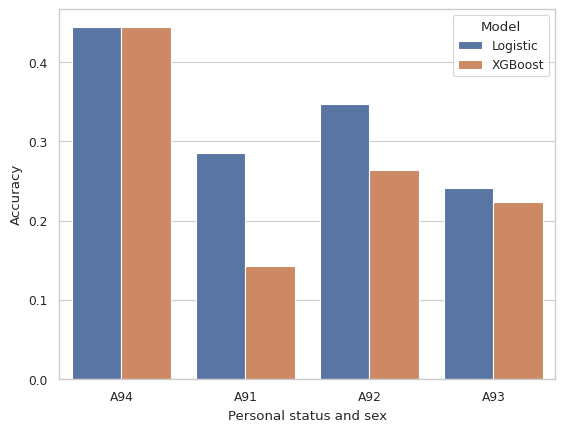

In [11]:
db = store.get_db()
db.attach(names=["predictions_test"], tags=["model", "german"])
db.attach(names=["german"])
with db.connect() as con:
    sql_result = con.sql(
        """
        select
            personal_status_sex AS 'Personal status and sex',
            case when p.logreg then 'Logistic' else 'XGBoost' end as Model,
            avg(case when y_true != predictions then 1 else 0 end) as Accuracy
        from predictions_test p
        join german d
        on p.uuid=d.uuid
        group by p.logreg, personal_status_sex
        """
    ).df()
_ = sns.barplot(sql_result, x="Personal status and sex", y="Accuracy", hue="Model")

With this, we've reached the end of this short example. As I hope you noticed, not once did we have to worry about filepaths, directory structure or where to store the results of our experiments. In the remaining examples, we'll see how to store, query and analyze hyperparameters and make filenames `model_x_lr=0.1_batch_size=512_cosine.csv` a thing of the past.